## Import libraries

In [103]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [104]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.float_format', '{:.4f}'.format)

## Load Data

In [ ]:
df = pd.read_parquet("/Users/tuongminh/Desktop/thesis/eurostar/data/processed/survey_and_operational_data.parquet")

print(df.shape)
df.head()

## Delay Cause Data

In [4]:
arrival_df = pd.read_excel('/Users/tuongminh/Desktop/thesis/eurostar/data/raw/Arrival delay - 20250101-20260531.xlsx')
df.to_csv('Arrival delay - 20250101-20260531.csv', index=False)
print(f'Done! Shape: {arrival_df.shape}')

Done! Shape: (46262, 12)


In [6]:
arrival_df['Origin Station Name'] = arrival_df['Origin Station Name'].replace({
    'Bruxelles-Midi': 'Brussels Midi / Zuid',
    'Amsterdam-Centraal': 'Amsterdam Centraal',
    'Köln Hbf': 'Cologne Hbf',
    'Düsseldorf Hbf': 'Dusseldorf Hbf',
    'Lille-Europe': 'Lille Europe',
    'Marne-la-Vallée-Chessy': 'Disneyland Paris (Marne-la-Vallée Chessy)',
    'Paris-Nord': 'Paris Gare du Nord',
    'Roissy-Airport-CDG 2': 'Paris-Charles de Gaulle Airport',
    'St-Pancras-International': "London St Pancras Int'l",
    'Rotterdam-Centraal': 'Rotterdam Centraal',
    'Schiphol Airport': 'Schiphol Airport'
})

arrival_df['Destination Station Name'] = arrival_df['Destination Station Name'].replace({
    'Bruxelles-Midi': 'Brussels Midi / Zuid',
    'Amsterdam-Centraal': 'Amsterdam Centraal',
    'Köln Hbf': 'Cologne Hbf',
    'Düsseldorf Hbf': 'Dusseldorf Hbf',
    'Lille-Europe': 'Lille Europe',
    'Marne-la-Vallée-Chessy': 'Disneyland Paris (Marne-la-Vallée Chessy)',
    'Paris-Nord': 'Paris Gare du Nord',
    'Roissy-Airport-CDG 2': 'Paris-Charles de Gaulle Airport',
    'St-Pancras-International': "London St Pancras Int'l",
    'Rotterdam-Centraal': 'Rotterdam Centraal',
    'Schiphol Airport': 'Schiphol Airport'
})

In [7]:
departure_df = pd.read_excel('/Users/tuongminh/Desktop/thesis/eurostar/data/raw/Departure delay - 20250101-20260531.xlsx')
df.to_csv('Departure delay - 20250101-20260531.csv', index=False)
print(f'Done! Shape: {departure_df.shape}')

Done! Shape: (52870, 9)


In [8]:
departure_df['Origin Station Name'] = departure_df['Origin Station Name'].replace({
    'Bruxelles-Midi': 'Brussels Midi / Zuid',
    'Amsterdam-Centraal': 'Amsterdam Centraal',
    'Köln Hbf': 'Cologne Hbf',
    'Düsseldorf Hbf': 'Dusseldorf Hbf',
    'Lille-Europe': 'Lille Europe',
    'Marne-la-Vallée-Chessy': 'Disneyland Paris (Marne-la-Vallée Chessy)',
    'Paris-Nord': 'Paris Gare du Nord',
    'Roissy-Airport-CDG 2': 'Paris-Charles de Gaulle Airport',
    'St-Pancras-International': "London St Pancras Int'l",
    'Rotterdam-Centraal': 'Rotterdam Centraal',
    'Schiphol Airport': 'Schiphol Airport'
})

departure_df['Destination Station Name'] = departure_df['Destination Station Name'].replace({
    'Bruxelles-Midi': 'Brussels Midi / Zuid',
    'Amsterdam-Centraal': 'Amsterdam Centraal',
    'Köln Hbf': 'Cologne Hbf',
    'Düsseldorf Hbf': 'Dusseldorf Hbf',
    'Lille-Europe': 'Lille Europe',
    'Marne-la-Vallée-Chessy': 'Disneyland Paris (Marne-la-Vallée Chessy)',
    'Paris-Nord': 'Paris Gare du Nord',
    'Roissy-Airport-CDG 2': 'Paris-Charles de Gaulle Airport',
    'St-Pancras-International': "London St Pancras Int'l",
    'Rotterdam-Centraal': 'Rotterdam Centraal',
    'Schiphol Airport': 'Schiphol Airport'
})

In [9]:
departure_df['Departure Date'] = pd.to_datetime(
    departure_df['Departure Date'],
    errors='coerce'
)

arrival_df['Departure Date'] = pd.to_datetime(
    arrival_df['Departure Date'],
    errors='coerce'
)

departure_df = departure_df.dropna(subset=['Departure Date'])
arrival_df = arrival_df.dropna(subset=['Departure Date'])

In [10]:
departure_df['join_key'] = (
    departure_df['Movement Number'] + '_' +
    departure_df['Departure Date'].dt.strftime('%Y%m%d') + '_' +
    departure_df['Origin Station Name'] + '_' +
    departure_df['Destination Station Name']
)

arrival_df['join_key'] = (
    arrival_df['Movement Number'] + '_' +
    arrival_df['Departure Date'].dt.strftime('%Y%m%d') + '_' +
    arrival_df['Origin Station Name'] + '_' +
    arrival_df['Destination Station Name']
)

In [11]:
# remove bad row
departure_df = departure_df.dropna(subset=['Departure Date'])
arrival_df = arrival_df.dropna(subset=['Departure Date'])

In [12]:
delay_merged = departure_df.merge(
    arrival_df[
        ['join_key', 'Arrival Delay (Minutes)', 'Is Station Departure Service', 'Cause Category',	'Cause Domain']
    ],
    on='join_key',
    how='left'
)

In [14]:
delay_merged.shape

(111032, 14)

In [16]:
london = "London St Pancras Int'l"

# fix departure delay FROM London
mask_london_dep = delay_merged['Origin Station Name'] == london
delay_merged.loc[mask_london_dep, 'Departure Delay (Minutes)'] += 60

# fix arrival delay TO London
mask_london_arr = delay_merged['Destination Station Name'] == london
delay_merged.loc[mask_london_arr, 'Arrival Delay (Minutes)'] += 60

print(f'Fixed {mask_london_dep.sum()} departure records from London')
print(f'Fixed {mask_london_arr.sum()} arrival records to London')

# sanity check - should see reasonable delay distribution now
print('\nLondon departure delays after fix:')
print(delay_merged[mask_london_dep]['Departure Delay (Minutes)'].describe().round(2))

Fixed 6041 departure records from London
Fixed 8169 arrival records to London

London departure delays after fix:
count   6041.0000
mean      63.8900
std       18.5900
min       -2.0000
25%       59.9000
50%       60.0000
75%       61.4000
max      249.0000
Name: Departure Delay (Minutes), dtype: float64


## Station NPS Exploration

In [17]:
route_nps = (
    df.groupby('metadata_origin_station')
    .agg(
        mean_nps=('metadata_recommendation_nps_a', 'mean'),
        response_count=('metadata_recommendation_nps_a', 'count')
    )
    .reset_index()
    .rename(columns={'metadata_origin_station': 'Origin Station Name'})
)

print(route_nps.sort_values('mean_nps',ascending=False).to_string(index=False, float_format='%.4f'))

                      Origin Station Name  mean_nps  response_count
                       Dusseldorf Airport    9.3333               3
         Moutiers Salins Brides Les Bains    9.0000               2
                             Lille Europe    8.4829            4405
                             Dortmund Hbf    8.4178             359
                                Essen Hbf    8.4031             258
                  London St Pancras Int'l    8.2887           59042
                              Cologne Hbf    8.1879            4806
Disneyland Paris (Marne-la-Vallée Chessy)    8.1330             203
                             Duisburg Hbf    8.1154             130
          Paris-Charles de Gaulle Airport    8.1038             183
                               Aachen Hbf    8.0569             808
                     Brussels Midi / Zuid    8.0335           28421
                           Dusseldorf Hbf    7.9734             564
                       Paris Gare du Nord    7.9

In [18]:
# std of NPS per origin across its destinations
route_variance = (
    df.groupby(['metadata_origin_station', 'metadata_destination_station'])
    ['metadata_recommendation_nps_a'].mean()
    .groupby(level='metadata_origin_station')
    .std()
    .sort_values(ascending=False)
)
print(route_variance.head(10))

metadata_origin_station
Rotterdam Centraal                          1.8936
Aachen Hbf                                  1.5886
Moutiers Salins Brides Les Bains            1.4142
Liege-Guillemins                            1.1667
Duisburg Hbf                                1.0367
Cologne Hbf                                 0.9903
Dortmund Hbf                                0.9588
Antwerpen-Centraal                          0.8654
Essen Hbf                                   0.7932
Disneyland Paris (Marne-la-Vallée Chessy)   0.7071
Name: metadata_recommendation_nps_a, dtype: float64


In [19]:
route_stats = (
    df.groupby(['metadata_origin_station', 'metadata_destination_station'])
    .agg(
        avg_dep_delay=('early_journey_delay_minute', 'mean'),
        avg_arr_delay=('arrival_delay_minute', 'mean'),
        total_services=('service_id', 'count')
    )
    .reset_index()
)

print(f'Routes: {len(route_stats)}')
print(route_stats.head(10).to_string(index=False))

Routes: 104
metadata_origin_station              metadata_destination_station  avg_dep_delay  avg_arr_delay  total_services
             Aachen Hbf                      Brussels Midi / Zuid         3.3900        13.1600             100
             Aachen Hbf                               Cologne Hbf         0.0000         4.0000               1
             Aachen Hbf                          Liege-Guillemins         7.6667        10.0000               3
             Aachen Hbf                        Paris Gare du Nord         6.0341        16.0966             704
     Amsterdam Centraal                        Antwerpen-Centraal         6.0746        17.4884             389
     Amsterdam Centraal                      Brussels Midi / Zuid         6.7898        16.5170            1327
     Amsterdam Centraal Disneyland Paris (Marne-la-Vallée Chessy)         6.1935        16.3387              62
     Amsterdam Centraal                   London St Pancras Int'l         7.9848        16.5

In [106]:
routes = (
    df[['metadata_origin_station', 'metadata_destination_station']].
    drop_duplicates().rename(columns = {
        'metadata_origin_station': 'origin_station',
        'metadata_destination_station': 'destination_station'
    }).dropna()
)

print (f'Unique routes: {len(routes)}')
print (f'Unique stations: {routes[['origin_station', 'destination_station']]
                           .stack().nunique()}')
print ('\nSample routes:')
print (routes.head(10).to_string (index = False))

Unique routes: 104
Unique stations: 20

Sample routes:
         origin_station     destination_station
London St Pancras Int'l      Amsterdam Centraal
   Brussels Midi / Zuid London St Pancras Int'l
London St Pancras Int'l    Brussels Midi / Zuid
     Amsterdam Centraal      Paris Gare du Nord
     Paris Gare du Nord London St Pancras Int'l
     Paris Gare du Nord      Amsterdam Centraal
     Paris Gare du Nord    Brussels Midi / Zuid
London St Pancras Int'l      Rotterdam Centraal
London St Pancras Int'l      Paris Gare du Nord
   Brussels Midi / Zuid      Paris Gare du Nord


## Create Graph

In [107]:
G = nx.DiGraph()

for _, row in routes.iterrows():
    G.add_edge (row['origin_station'], row ['destination_station'])

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')
print(f'Stations: {sorted(G.nodes())}')

Nodes: 20
Edges: 104
Stations: ['Aachen Hbf', 'Amsterdam Centraal', 'Antwerpen-Centraal', 'Brussels Midi / Zuid', 'Chambery - Challes-les-Eaux', 'Cologne Hbf', 'Disneyland Paris (Marne-la-Vallée Chessy)', 'Dortmund Hbf', 'Duisburg Hbf', 'Dusseldorf Airport', 'Dusseldorf Hbf', 'Essen Hbf', 'Liege-Guillemins', 'Lille Europe', "London St Pancras Int'l", 'Moutiers Salins Brides Les Bains', 'Paris Gare du Nord', 'Paris-Charles de Gaulle Airport', 'Rotterdam Centraal', 'Schiphol Airport']


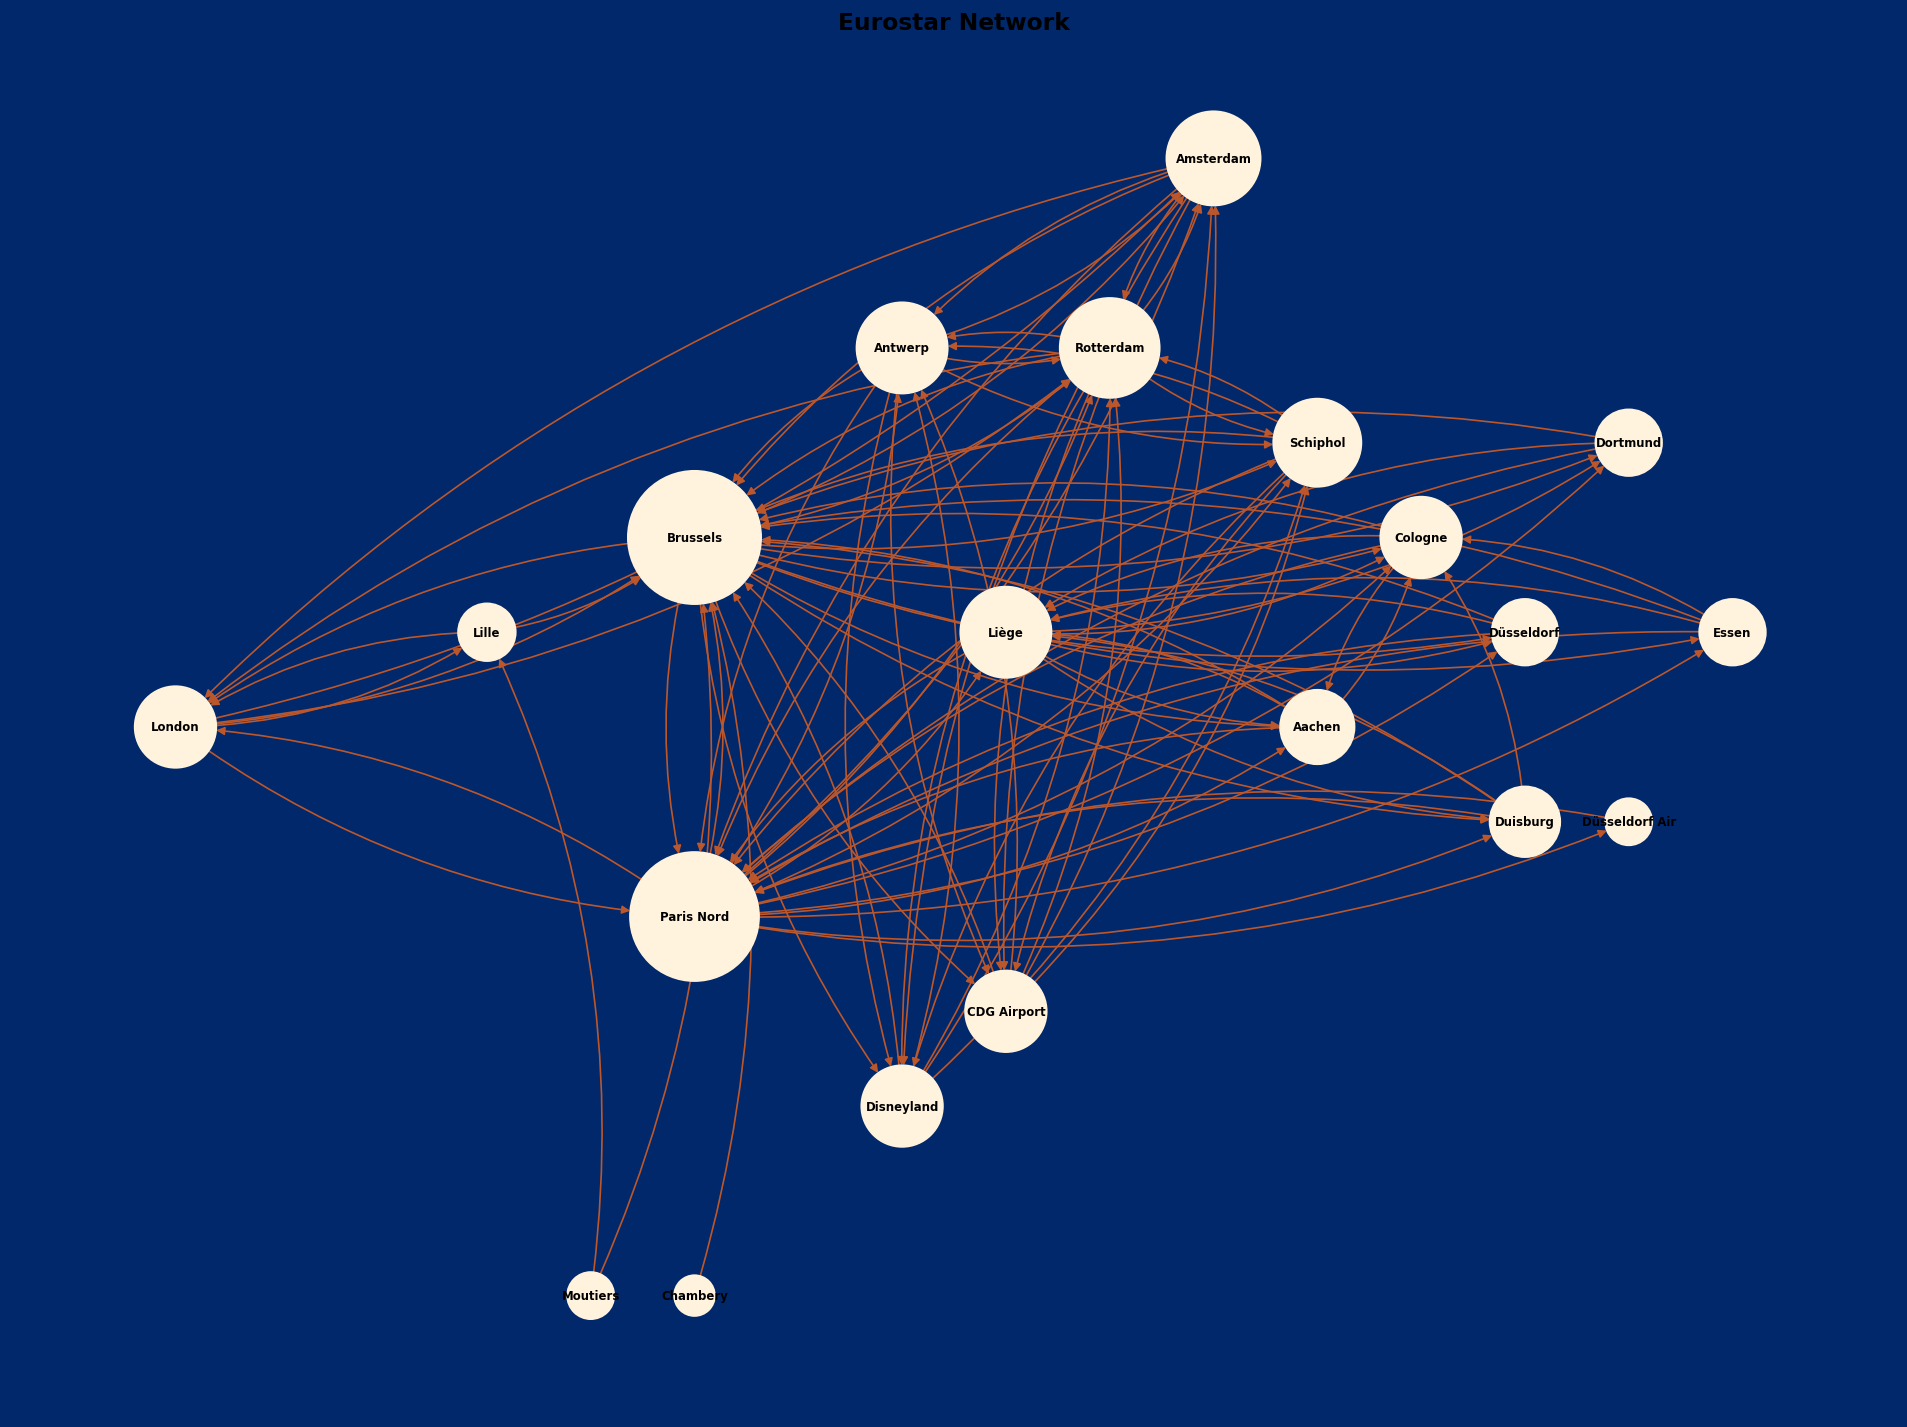

In [111]:
# manual geographic positions
pos = {
    "London St Pancras Int'l":                    (-3, 0),
    'Brussels Midi / Zuid':                        (-0.5, 1),
    'Paris Gare du Nord':                          (-0.5, -1),
    'Amsterdam Centraal':                          (2, 3),
    'Rotterdam Centraal':                          (1.5, 2),
    'Schiphol Airport':                            (2.5, 1.5),
    'Lille Europe':                                (-1.5, 0.5),
    'Antwerpen-Centraal':                          (0.5, 2),
    'Liege-Guillemins':                            (1, 0.5),
    'Cologne Hbf':                                 (3, 1),
    'Aachen Hbf':                                  (2.5, 0),
    'Dusseldorf Hbf':                              (3.5, 0.5),
    'Dusseldorf Airport':                          (4, -0.5),
    'Dortmund Hbf':                                (4, 1.5),
    'Duisburg Hbf':                                (3.5, -0.5),
    'Essen Hbf':                                   (4.5, 0.5),
    'Disneyland Paris (Marne-la-Vallée Chessy)':  (0.5, -2),
    'Paris-Charles de Gaulle Airport':             (1, -1.5),
    'Moutiers Salins Brides Les Bains':            (-1, -3),
    'Chambery - Challes-les-Eaux':                 (-0.5, -3),
}
short_labels = {
    "London St Pancras Int'l":                   'London',
    'Brussels Midi / Zuid':                       'Brussels',
    'Paris Gare du Nord':                         'Paris Nord',
    'Amsterdam Centraal':                         'Amsterdam',
    'Rotterdam Centraal':                         'Rotterdam',
    'Schiphol Airport':                           'Schiphol',
    'Lille Europe':                               'Lille',
    'Antwerpen-Centraal':                         'Antwerp',
    'Liege-Guillemins':                           'Liège',
    'Cologne Hbf':                                'Cologne',
    'Aachen Hbf':                                 'Aachen',
    'Dusseldorf Hbf':                             'Düsseldorf',
    'Dusseldorf Airport':                         'Düsseldorf Air',
    'Dortmund Hbf':                               'Dortmund',
    'Duisburg Hbf':                               'Duisburg',
    'Essen Hbf':                                  'Essen',
    'Disneyland Paris (Marne-la-Vallée Chessy)': 'Disneyland',
    'Paris-Charles de Gaulle Airport':            'CDG Airport',
    'Moutiers Salins Brides Les Bains':           'Moutiers',
    'Chambery - Challes-les-Eaux':                'Chambery',
}

fig, ax = plt.subplots(figsize=(16, 12), facecolor='#00286a', dpi = 120)

node_sizes = [400 + 200 * G.degree(n) for n in G.nodes()]

nx.draw(G, pos, ax=ax,
    with_labels=True,
    labels=short_labels,
    node_size=node_sizes,
    node_color='#fff3dd',
    font_size=7,
    font_color='black',
    font_weight='bold',
    edge_color='#bc572c',
    width=1,
    arrows=True,
    arrowsize=10,
    connectionstyle='arc3,rad=0.15'
)
plt.gcf().patch.set_facecolor('#00286a')
ax.axis('off')
ax.set_title('Eurostar Network', fontsize=14, fontweight='bold')
ax.set_facecolor('#00286a')
plt.tight_layout()
plt.show()

In [23]:
# number of stations
print(f'Unique nodes: {G.number_of_nodes()}')
print(sorted(G.nodes()))

Unique nodes: 20
['Aachen Hbf', 'Amsterdam Centraal', 'Antwerpen-Centraal', 'Brussels Midi / Zuid', 'Chambery - Challes-les-Eaux', 'Cologne Hbf', 'Disneyland Paris (Marne-la-Vallée Chessy)', 'Dortmund Hbf', 'Duisburg Hbf', 'Dusseldorf Airport', 'Dusseldorf Hbf', 'Essen Hbf', 'Liege-Guillemins', 'Lille Europe', "London St Pancras Int'l", 'Moutiers Salins Brides Les Bains', 'Paris Gare du Nord', 'Paris-Charles de Gaulle Airport', 'Rotterdam Centraal', 'Schiphol Airport']


**Calculate Centrality**

In [24]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

In [25]:
centrality_df = pd.DataFrame({
    'station': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': [betweenness_centrality[k] for k in degree_centrality.keys()],
    'closeness_centrality': [closeness_centrality[k] for k in degree_centrality.keys()]
}).sort_values('betweenness_centrality', ascending=False).reset_index(drop=True)
centrality_df

,station,degree_centrality,betweenness_centrality,closeness_centrality
0,Brussels Midi / Zuid,1.5789,0.3412,0.9048
1,Paris Gare du Nord,1.4737,0.2836,0.7917
2,London St Pancras Int'l,0.5263,0.0569,0.5758
3,Rotterdam Centraal,0.8421,0.0213,0.6333
4,Liege-Guillemins,0.6842,0.0200,0.5278
5,Amsterdam Centraal,0.7368,0.0174,0.6129
6,Schiphol Airport,0.6316,0.0088,0.5938
7,Antwerpen-Centraal,0.6842,0.0079,0.5429
8,Cologne Hbf,0.5263,0.0047,0.5938
9,Dusseldorf Hbf,0.3158,0.0032,0.5429


In [26]:
print ('Top 5 by betweenness:')
print (centrality_df.sort_values ('betweenness_centrality', ascending = False).head(5).round(4).to_string())

Top 5 by betweenness:
                   station  degree_centrality  betweenness_centrality  closeness_centrality
0     Brussels Midi / Zuid             1.5789                  0.3412                0.9048
1       Paris Gare du Nord             1.4737                  0.2836                0.7917
2  London St Pancras Int'l             0.5263                  0.0569                0.5758
3       Rotterdam Centraal             0.8421                  0.0213                0.6333
4         Liege-Guillemins             0.6842                  0.0200                0.5278


In [27]:
centrality_df['criticality_score'] = (
    0.3 * centrality_df['degree_centrality'] +
    0.5 * centrality_df['betweenness_centrality'] +
    0.2 * centrality_df['closeness_centrality']
)

In [28]:
threshold = centrality_df['criticality_score'].quantile(0.9)

centrality_df['is_critical'] = centrality_df['criticality_score'] >= threshold

In [29]:
centrality_df

,station,degree_centrality,betweenness_centrality,closeness_centrality,criticality_score,is_critical
0,Brussels Midi / Zuid,1.5789,0.3412,0.9048,0.8252,True
1,Paris Gare du Nord,1.4737,0.2836,0.7917,0.7422,True
2,London St Pancras Int'l,0.5263,0.0569,0.5758,0.3015,False
3,Rotterdam Centraal,0.8421,0.0213,0.6333,0.3899,False
4,Liege-Guillemins,0.6842,0.0200,0.5278,0.3208,False
5,Amsterdam Centraal,0.7368,0.0174,0.6129,0.3523,False
6,Schiphol Airport,0.6316,0.0088,0.5938,0.3126,False
7,Antwerpen-Centraal,0.6842,0.0079,0.5429,0.3178,False
8,Cologne Hbf,0.5263,0.0047,0.5938,0.2790,False
9,Dusseldorf Hbf,0.3158,0.0032,0.5429,0.2049,False


In [112]:
# merge with NPS
station_nps = (df.groupby ('metadata_origin_station')['metadata_recommendation_nps_a']
               .agg(mean_nps = 'mean', n_responses = 'count')
               .reset_index()
               .rename(columns = {'metadata_origin_station': 'station'})
               )

station_analysis = centrality_df.merge(
    station_nps,
    on="station",
    how="left"
)
station_analysis = station_analysis[station_analysis['n_responses'] >= 50]

print (f'\nStation analysis table ({len(station_analysis)} stations with more than 50 responses):')
print (station_analysis.sort_values('criticality_score', ascending = False).round(3).to_string())


Station analysis table (17 stations with more than 50 responses):
                                      station  degree_centrality  betweenness_centrality  closeness_centrality  criticality_score  is_critical  mean_nps  n_responses
0                        Brussels Midi / Zuid             1.5790                  0.3410                0.9050             0.8250         True    8.0330        28421
1                          Paris Gare du Nord             1.4740                  0.2840                0.7920             0.7420         True    7.9530        57461
3                          Rotterdam Centraal             0.8420                  0.0210                0.6330             0.3900        False    7.8370         6803
5                          Amsterdam Centraal             0.7370                  0.0170                0.6130             0.3520        False    7.6790        11121
4                            Liege-Guillemins             0.6840                  0.0200               

## Average Delay per Station

In [31]:
# average departure delay per station
dep_station = (
    df.groupby(['metadata_origin_station'])
    .agg(
        avg_dep_delay=('early_journey_delay_minute', 'mean'),
        total_services=('service_id', 'count')
    )
).reset_index().rename(columns = {'metadata_origin_station': 'station'})

In [32]:
dep_station

,station,avg_dep_delay,total_services
0,Aachen Hbf,5.7054,808
1,Amsterdam Centraal,6.6683,11121
2,Antwerpen-Centraal,5.3104,1440
3,Brussels Midi / Zuid,6.8279,28421
4,Chambery - Challes-les-Eaux,0.0000,1
5,Cologne Hbf,6.4480,4806
6,Disneyland Paris (Marne-la-Vallée Chessy),3.7192,203
7,Dortmund Hbf,4.4318,359
8,Duisburg Hbf,3.5692,130
9,Dusseldorf Airport,0.0000,3


In [33]:
dep_station = dep_station[dep_station['total_services'] >= 50]

In [34]:
# average arrival delay per station
arr_station = (
    df.groupby(['metadata_destination_station'])
    .agg(
        avg_arr_delay=('arrival_delay_minute', 'mean'),
        total_services=('service_id', 'count')
    )
).reset_index().rename(columns = {'metadata_destination_station': 'station'})

In [35]:
arr_station

,station,avg_arr_delay,total_services
0,Aachen Hbf,21.5056,536
1,Amsterdam Centraal,18.1347,11501
2,Antwerpen-Centraal,20.1166,1347
3,Brussels Midi / Zuid,10.5968,28826
4,Cologne Hbf,22.2201,3662
5,Disneyland Paris (Marne-la-Vallée Chessy),13.2361,288
6,Dortmund Hbf,27.0135,222
7,Duisburg Hbf,28.7634,93
8,Dusseldorf Airport,106.0000,1
9,Dusseldorf Hbf,27.3339,548


In [36]:
arr_station = arr_station[arr_station['total_services'] >= 50]

In [37]:
station_analysis = station_analysis.merge(dep_station[['avg_dep_delay','station']], on='station', how='left')

In [38]:
station_analysis = station_analysis.merge(arr_station[['avg_arr_delay','station']], on='station', how='left')

In [39]:
station_analysis

,station,degree_centrality,betweenness_centrality,closeness_centrality,criticality_score,is_critical,mean_nps,n_responses,avg_dep_delay,avg_arr_delay
0,Brussels Midi / Zuid,1.5789,0.3412,0.9048,0.8252,True,8.0335,28421,6.8279,10.5968
1,Paris Gare du Nord,1.4737,0.2836,0.7917,0.7422,True,7.9530,57461,7.7727,10.6515
2,London St Pancras Int'l,0.5263,0.0569,0.5758,0.3015,False,8.2887,59042,3.1322,12.0109
3,Rotterdam Centraal,0.8421,0.0213,0.6333,0.3899,False,7.8365,6803,5.7541,18.8436
4,Liege-Guillemins,0.6842,0.0200,0.5278,0.3208,False,7.6940,1160,6.0655,22.0816
5,Amsterdam Centraal,0.7368,0.0174,0.6129,0.3523,False,7.6788,11121,6.6683,18.1347
6,Schiphol Airport,0.6316,0.0088,0.5938,0.3126,False,7.6753,1663,4.5695,21.1032
7,Antwerpen-Centraal,0.6842,0.0079,0.5429,0.3178,False,7.3688,1440,5.3104,20.1166
8,Cologne Hbf,0.5263,0.0047,0.5938,0.2790,False,8.1879,4806,6.4480,22.2201
9,Dusseldorf Hbf,0.3158,0.0032,0.5429,0.2049,False,7.9734,564,5.3564,27.3339


## Route Delay

In [40]:
route_early_delay = (
    df.groupby(['metadata_origin_station','route_type'])
    .agg(
        avg_early_delay=('early_journey_delay_minute', 'mean'),
        total_services=('service_id', 'count')
    )
).reset_index().rename(columns = {'metadata_origin_station': 'station'})

In [41]:
route_early_delay = route_early_delay[route_early_delay['total_services'] >= 50]

In [42]:
channel_delay = (
    route_early_delay[route_early_delay['route_type'] == 'Channel']
    [['station', 'avg_early_delay']]
    .rename(columns={'avg_early_delay': 'channel_avg_early_delay'})
)

station_analysis = station_analysis.merge(
    channel_delay,
    on='station',
    how='left'
)

In [43]:
continental_delay = (
    route_early_delay[route_early_delay['route_type'] == 'Continental']
    [['station', 'avg_early_delay']]
    .rename(columns={'avg_early_delay': 'continental_avg_early_delay'})
)

station_analysis = station_analysis.merge(
    continental_delay,
    on='station',
    how='left'
)

In [44]:
route_arr_delay = (
    df.groupby(['metadata_destination_station','route_type'])
    .agg(
        avg_arr_delay=('arrival_delay_minute', 'mean'),
        total_services=('service_id', 'count')
    )
).reset_index().rename(columns = {'metadata_destination_station': 'station'})

In [45]:
route_arr_delay = route_arr_delay[route_arr_delay['total_services'] >= 50]

In [46]:
channel_arr_delay = (
    route_arr_delay[route_arr_delay['route_type'] == 'Channel']
    [['station', 'avg_arr_delay']]
    .rename(columns={'avg_arr_delay': 'channel_avg_arr_delay'})
)

station_analysis = station_analysis.merge(
    channel_arr_delay,
    on='station',
    how='left'
)

In [47]:
continental_arr_delay = (
    route_arr_delay[route_arr_delay['route_type'] == 'Continental']
    [['station', 'avg_arr_delay']]
    .rename(columns={'avg_arr_delay': 'continental_avg_arr_delay'})
)

station_analysis = station_analysis.merge(
    continental_arr_delay,
    on='station',
    how='left'
)

In [48]:
station_analysis

,station,degree_centrality,betweenness_centrality,closeness_centrality,criticality_score,is_critical,mean_nps,n_responses,avg_dep_delay,avg_arr_delay,channel_avg_early_delay,continental_avg_early_delay,channel_avg_arr_delay,continental_avg_arr_delay
0,Brussels Midi / Zuid,1.5789,0.3412,0.9048,0.8252,True,8.0335,28421,6.8279,10.5968,7.2339,6.4205,7.0311,14.1021
1,Paris Gare du Nord,1.4737,0.2836,0.7917,0.7422,True,7.9530,57461,7.7727,10.6515,7.6101,7.9733,6.8895,15.0955
2,London St Pancras Int'l,0.5263,0.0569,0.5758,0.3015,False,8.2887,59042,3.1322,12.0109,3.1322,NaN,12.0109,NaN
3,Rotterdam Centraal,0.8421,0.0213,0.6333,0.3899,False,7.8365,6803,5.7541,18.8436,7.9360,4.6658,12.8921,22.4226
4,Liege-Guillemins,0.6842,0.0200,0.5278,0.3208,False,7.6940,1160,6.0655,22.0816,NaN,6.0655,NaN,22.0816
5,Amsterdam Centraal,0.7368,0.0174,0.6129,0.3523,False,7.6788,11121,6.6683,18.1347,7.9848,5.8833,12.9076,21.4566
6,Schiphol Airport,0.6316,0.0088,0.5938,0.3126,False,7.6753,1663,4.5695,21.1032,NaN,4.5695,NaN,21.1032
7,Antwerpen-Centraal,0.6842,0.0079,0.5429,0.3178,False,7.3688,1440,5.3104,20.1166,NaN,5.3104,NaN,20.1166
8,Cologne Hbf,0.5263,0.0047,0.5938,0.2790,False,8.1879,4806,6.4480,22.2201,NaN,6.4480,NaN,22.2201
9,Dusseldorf Hbf,0.3158,0.0032,0.5429,0.2049,False,7.9734,564,5.3564,27.3339,NaN,5.3564,NaN,27.3339


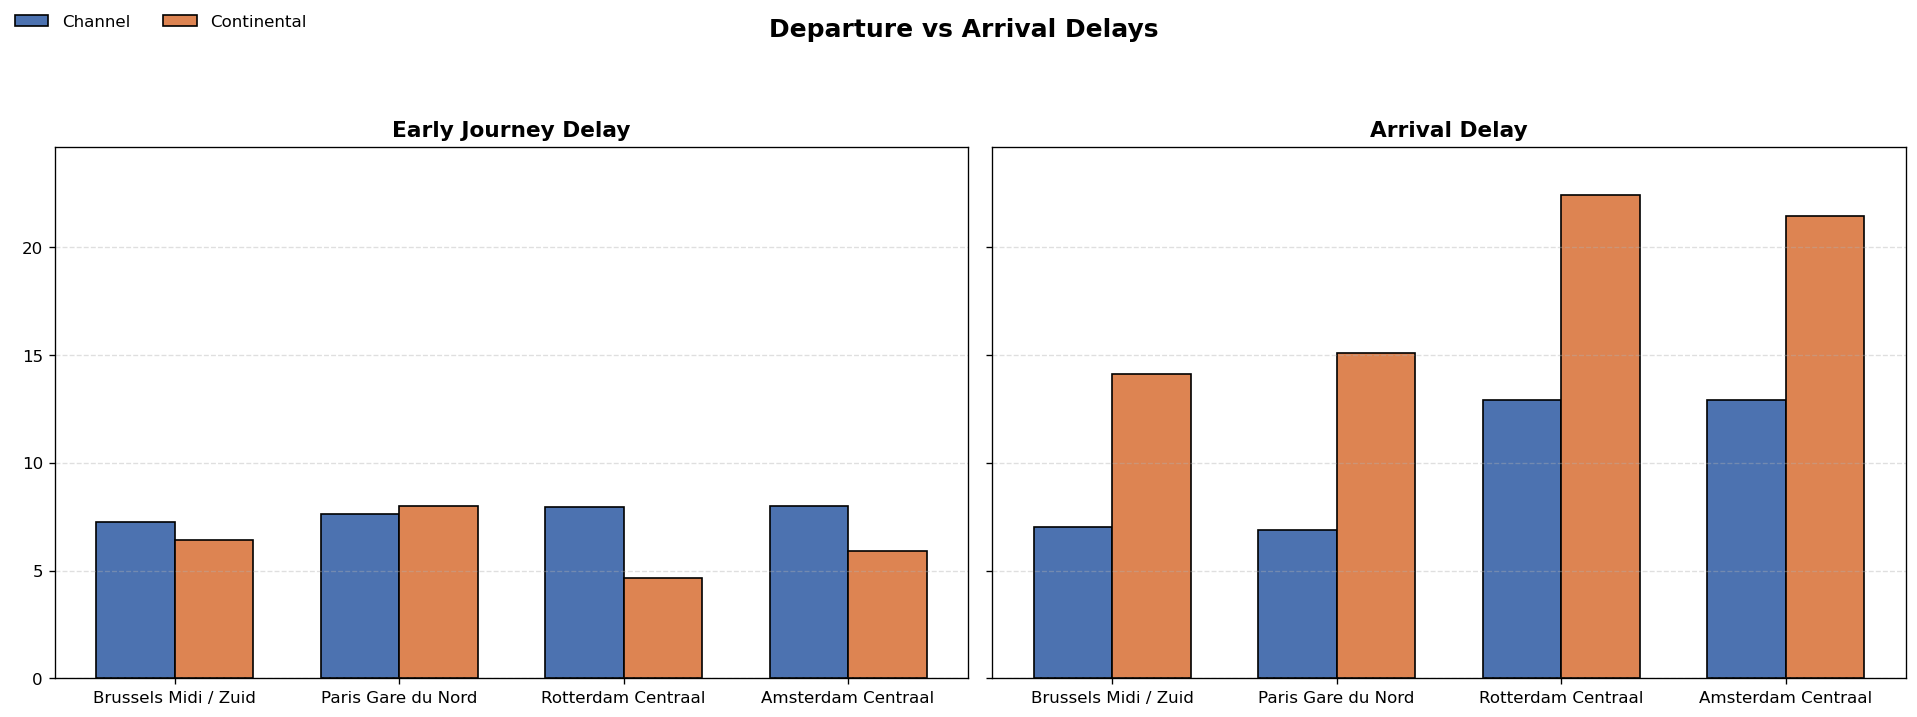

In [49]:
selected = station_analysis[
    station_analysis['station'].isin([
        'Brussels Midi / Zuid',
        'Paris Gare du Nord',
        'Rotterdam Centraal',
        'Amsterdam Centraal'
    ])
].copy()

order = [
    'Brussels Midi / Zuid',
    'Paris Gare du Nord',
    'Rotterdam Centraal',
    'Amsterdam Centraal'
]

selected['station'] = pd.Categorical(selected['station'], categories=order, ordered=True)
selected = selected.sort_values('station')

stations = selected['station']
x = np.arange(len(stations))
width = 0.35

y_max = max(
    selected['channel_avg_early_delay'].max(),
    selected['continental_avg_early_delay'].max(),
    selected['channel_avg_arr_delay'].max(),
    selected['continental_avg_arr_delay'].max()
) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=120, sharey=True)

axes[0].bar(x - width/2, selected['channel_avg_early_delay'],
            width, label='Channel', color='#4C72B0', edgecolor='black')

axes[0].bar(x + width/2, selected['continental_avg_early_delay'],
            width, label='Continental', color='#DD8452', edgecolor='black')

axes[0].set_title("Early Journey Delay", fontsize=13, weight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stations)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].set_ylim(0, y_max)

axes[1].bar(x - width/2, selected['channel_avg_arr_delay'],
            width, label='Channel', color='#4C72B0', edgecolor='black')

axes[1].bar(x + width/2, selected['continental_avg_arr_delay'],
            width, label='Continental', color='#DD8452', edgecolor='black')

axes[1].set_title("Arrival Delay", fontsize=13, weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stations)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].set_ylim(0, y_max)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=False)

plt.suptitle("Departure vs Arrival Delays", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

/var/folders/l8/kz7n7phs2lqc80l_1n62zh2w0000gn/T/ipykernel_11897/3133018769.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(stations)
/var/folders/l8/kz7n7phs2lqc80l_1n62zh2w0000gn/T/ipykernel_11897/3133018769.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(stations)


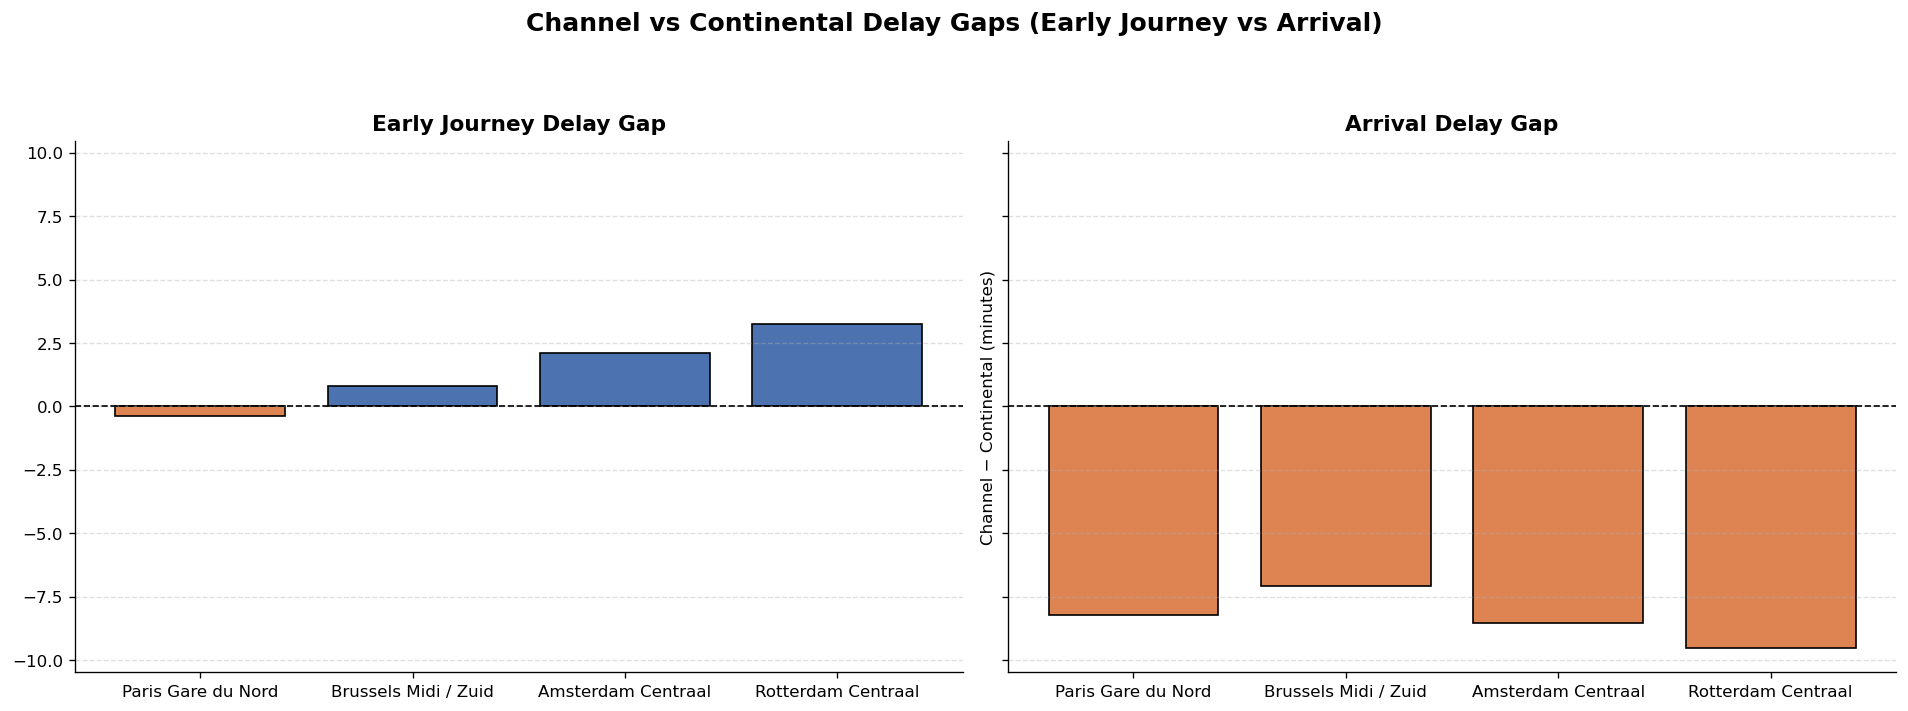

In [ ]:
# compute gaps
station_analysis['arr_delay_gap'] = station_analysis['channel_avg_arr_delay'] - station_analysis['continental_avg_arr_delay']
station_analysis['early_delay_gap'] = station_analysis['channel_avg_early_delay'] - station_analysis['continental_avg_early_delay']

plot_df = station_analysis.sort_values('early_delay_gap')

stations = plot_df['station']
x = np.arange(len(stations))

fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=120, sharey=True)

# shared y-limit for fairness
y_max = max(
    plot_df['arr_delay_gap'].abs().max(),
    plot_df['early_delay_gap'].abs().max()
) * 1.1

axes[1].bar(
    stations,
    plot_df['arr_delay_gap'],
    color=np.where(plot_df['arr_delay_gap'] >= 0, '#4C72B0', '#DD8452'),
    edgecolor='black'
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Arrival Delay Gap", fontsize=13, weight='bold')
axes[1].set_ylabel("Channel − Continental (minutes)")
axes[1].set_xticklabels(stations)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].set_ylim(-y_max, y_max)

axes[0].bar(
    stations,
    plot_df['early_delay_gap'],
    color=np.where(plot_df['early_delay_gap'] >= 0, '#4C72B0', '#DD8452'),
    edgecolor='black'
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title("Early Journey Delay Gap", fontsize=13, weight='bold')
axes[0].set_xticklabels(stations)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].set_ylim(-y_max, y_max)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Channel vs Continental Delay Gaps (Early Journey vs Arrival)", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [51]:
critical_stations = ['Brussels Midi / Zuid', 'Paris Gare du Nord']

In [52]:
df['is_critical'] = df['metadata_origin_station'].isin(critical_stations)

## Testing Hypotheses

**Hypotheses Testing**
- H1: Critical stations delays have bigger downstream impact
- H2: Certain routes may act as bottlenecks, higher betweenness centrality score correlates with higher delay variance
- H3: Passengers departing from critical stations report lower NPS

**Hypothesis 1**

In [54]:
cols = [
    'early_journey_delay_minute',
    'arrival_delay_minute',
    'is_critical'
]

df_h1 = df[cols].copy()

df_h1 = df_h1.replace([np.inf, -np.inf], np.nan)
df_h1 = df_h1.dropna()

In [55]:
df_h1['early_journey_delay_minute'] = df_h1['early_journey_delay_minute'].astype(float)
df_h1['arrival_delay_minute'] = df_h1['arrival_delay_minute'].astype(float)
df_h1['is_critical'] = df_h1['is_critical'].astype(int)

In [56]:
print(df_h1.nunique())

early_journey_delay_minute    199
arrival_delay_minute          269
is_critical                     2
dtype: int64


In [57]:
df_h1['interaction'] = (
    df_h1['early_journey_delay_minute'] * df_h1['is_critical']
)

In [58]:
import statsmodels.api as sm

X_h1 = df_h1[['early_journey_delay_minute', 'is_critical', 'interaction']]
X_h1 = sm.add_constant(X_h1)
y_h1 = df_h1['arrival_delay_minute']

model = sm.OLS(y_h1, X_h1).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     arrival_delay_minute   R-squared:                       0.496
Model:                              OLS   Adj. R-squared:                  0.496
Method:                   Least Squares   F-statistic:                 5.868e+04
Date:                  Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                          09:56:34   Log-Likelihood:            -7.9257e+05
No. Observations:                178833   AIC:                         1.585e+06
Df Residuals:                    178829   BIC:                         1.585e+06
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------


- When early journey delay = 0 and it is not a critical station, the expected arrival delay is about 5.7 minutes
- For non-critical stations, every additional minute of early delay is associated with approximately 1.17 additional minutes of arrival delay
- Holding early delay constant, critical stations have about 0.22 minutes more than arrival delay on average. The effect is statistically significant but operationally very small
- Interaction effect: the propagation effect is smaller for critical stations (highly significant)
-> Delays originating from critical stations propagate less strongly than delays originating from non-critical stations

This might due to the fact that critical stations (Brussels and Paris) have:
- More operational resources
- Greater scheduling buffers
- Better recovery mechanisms

- They act as shock absorbers, even though they are critical stations, they appear operationally resilient

**Hypothesis 2**

In [61]:
# calculate edge betweenness centrality
edge_bet = nx.edge_betweenness_centrality (G)

# create route
df['route'] = (df['metadata_origin_station'] +'->'+ df['metadata_destination_station'])

route_delay = (df.groupby(['metadata_origin_station','metadata_destination_station'])['arrival_delay_minute'].agg(delay_variance = 'var', n_trips = 'count').reset_index())

In [62]:
route_delay = route_delay.rename (columns = {
    'metadata_origin_station': 'Origin Station Name',
    'metadata_destination_station': 'Destination Station Name'
})

In [63]:
edge_df = pd.DataFrame ([
    {'Origin Station Name': u,
    'Destination Station Name': v,
    'edge_betweenness': ed} for (u,v), ed in edge_bet.items()
])

In [64]:
route_analysis = route_delay.merge(
    edge_df,
    on=['Origin Station Name', 'Destination Station Name'],
    how='left'
)

In [65]:
df_h2 = route_analysis.copy()

df_h2 = df_h2.replace([np.inf, -np.inf], np.nan)

df_h2 = df_h2.dropna(subset=['edge_betweenness', 'delay_variance'])

In [66]:
df_h2['edge_betweenness'] = pd.to_numeric(df_h2['edge_betweenness'], errors='coerce')
df_h2['delay_variance'] = pd.to_numeric(df_h2['delay_variance'], errors='coerce')

df_h2 = df_h2.dropna()

In [67]:
df_h2[['edge_betweenness', 'delay_variance']].corr()

,edge_betweenness,delay_variance
edge_betweenness,1.0000,0.0872
delay_variance,0.0872,1.0000


In [68]:
X_h2 = sm.add_constant(df_h2['edge_betweenness'])
y_h2 = df_h2['delay_variance']

model_h2 = sm.OLS(y_h2, X_h2).fit()
print(model_h2.summary())

                            OLS Regression Results                            
Dep. Variable:         delay_variance   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.7129
Date:                Sat, 20 Jun 2026   Prob (F-statistic):              0.401
Time:                        09:56:34   Log-Likelihood:                -783.97
No. Observations:                  95   AIC:                             1572.
Df Residuals:                      93   BIC:                             1577.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              638.9107    175.948  

The hypothesis is **not supported**. Route betweenness explains very little of the variation in delay variance. Even though edge betweenness identifies important routes in shortest paths, those routes are not necessarily the ones with unstable delays. Delay variance may be driven by something else: train frequency, station dwell time variability, etc. Structural centrality measures do not fully capture delay dynamics in railway transport system.

**Hypothesis 3**

In [69]:
df.groupby('is_critical')['metadata_recommendation_nps_a'].agg(['mean','count', 'std'])

,mean,count,std
is_critical,,,
False,8.1500,92951,2.1363
True,7.9796,85882,2.2373


In [70]:
df_h3 = df[['metadata_recommendation_nps_a', 'is_critical']].dropna()
df_h3['is_critical'] = df_h3['is_critical'].astype(int)

X_h3 = sm.add_constant(df_h3['is_critical'])
y_h3 = df_h3['metadata_recommendation_nps_a']

model_h3 = sm.OLS(y_h3, X_h3).fit()
print(model_h3.summary())

                                  OLS Regression Results                                 
Dep. Variable:     metadata_recommendation_nps_a   R-squared:                       0.002
Model:                                       OLS   Adj. R-squared:                  0.002
Method:                            Least Squares   F-statistic:                     271.2
Date:                           Sat, 20 Jun 2026   Prob (F-statistic):           6.79e-61
Time:                                   09:56:34   Log-Likelihood:            -3.9356e+05
No. Observations:                         178833   AIC:                         7.871e+05
Df Residuals:                             178831   BIC:                         7.871e+05
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------

Hypothesis 3 is **supported**. Non-critical stations have an average NPS of 8.15, while being in a critical station is associated with a 0.17 point lower NPS. The effect is highly statistically significant, but the effect size is very small.

In [71]:
df.columns = (
    df.columns
    .str.replace('question_at_the_station_', '')
    .str.replace('_', ' ')
    .str.strip()
)

In [97]:
cols = [
    'checking in to departures area', 
    'boarding the train',
    'toilets washrooms in the station',
    'the security process baggage checks and scanners',
    'passport control',
    'pre departure announcements in the station',
    'available space seating in the waiting area', 'the facilities in the waiting area',
    'the signage and directions to your platform and train', 'is critical', 'metadata recommendation nps a', 'route type']

station_h3 = df[cols].copy()

In [93]:
station_h3 = station_h3.apply(pd.to_numeric, errors = 'coerce')

In [98]:
station_h3 = station_h3.dropna()

In [99]:
station_h3.shape

(19500, 12)

In [102]:
station_h3['route type'].unique()

array(['Channel'], dtype=object)

This only applies to Channel route as passengers travelling on the Continental route have different circumstances regarding check-in and station experience.

In [77]:
station_h3['is critical'] = station_h3['is critical'].astype(int)
station_h3 = station_h3.astype ('float64')

In [78]:
print(station_h3.dtypes)

checking in to departures area                           float64
boarding the train                                       float64
toilets washrooms in the station                         float64
the security process baggage checks and scanners         float64
passport control                                         float64
pre departure announcements in the station               float64
available space seating in the waiting area              float64
the facilities in the waiting area                       float64
the signage and directions to your platform and train    float64
is critical                                              float64
metadata recommendation nps a                            float64
dtype: object


In [79]:
X_station = station_h3[[
    'checking in to departures area', 
    'boarding the train',
    'toilets washrooms in the station',
    'the security process baggage checks and scanners',
    'passport control',
    'pre departure announcements in the station',
    'available space seating in the waiting area', 'the facilities in the waiting area',
    'the signage and directions to your platform and train', 'is critical']]
X_station = sm.add_constant(X_station)
y_station = station_h3['metadata recommendation nps a']

model_station = sm.OLS(y_station, X_station).fit()
print(model_station.summary())

                                  OLS Regression Results                                 
Dep. Variable:     metadata recommendation nps a   R-squared:                       0.327
Model:                                       OLS   Adj. R-squared:                  0.327
Method:                            Least Squares   F-statistic:                     946.8
Date:                           Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                                   09:56:35   Log-Likelihood:                -38552.
No. Observations:                          19500   AIC:                         7.713e+04
Df Residuals:                              19489   BIC:                         7.721e+04
Df Model:                                     10                                         
Covariance Type:                       nonrobust                                         
                                                            coef    std err          t      P>|t|   

- Boarding the train is the most important driver of satisfaction station-wise
- Pre-boarding experience matters a lot
- Information clarity strongly improves satisfaction
- Comfort matters, but less than process flow
- Passport control has no meaningful effect on satisfaction
- Being in a critical station slightly increases NPS, since they may have better service quality

-> Passenger satisfaction is primarily driven by service and process quality at the station (boarding, check-in, information flow), while structural network properties (critical stations) have only a minor effect

## Delay Propagation

In [80]:
# delay increase
df['delay_increase'] = (df['arrival delay minute']-df['early journey delay minute'])

In [81]:
route_effect = df.groupby(['metadata origin station', 'metadata destination station']).agg(
    avg_delay_increase =('delay_increase','mean'),
    avg_delay = ('early journey delay minute', 'mean'), n = ('delay_increase', 'count')).reset_index()


In [82]:
route_effect = route_effect.rename(columns = {
    'metadata origin station' : 'Origin Station Name',
    'metadata destination station': 'Destination Station Name'
})

In [83]:
route_analysis = route_analysis.merge(route_effect, 
on =['Origin Station Name', 'Destination Station Name'], how = 'left')

In [84]:
df['delay_bin'] = pd.cut(
    df['early journey delay minute'],
    bins=[0, 5, 10, 15, 30, 60],
    labels=['0-5', '5-10', '10-15', '15-30', '30+']
)

bin_effect = df.groupby('delay_bin')['delay_increase'].mean()
print(bin_effect)

delay_bin
0-5      7.0104
5-10     5.8946
10-15   11.0029
15-30   11.3097
30+     12.1554
Name: delay_increase, dtype: float64


/var/folders/l8/kz7n7phs2lqc80l_1n62zh2w0000gn/T/ipykernel_11897/2956642407.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_effect = df.groupby('delay_bin')['delay_increase'].mean()


- Not linear
- There is a tipping point around 10-15 minutes, after 10 minutes of delay, delays stop being local and start propagating through the network much more strongly

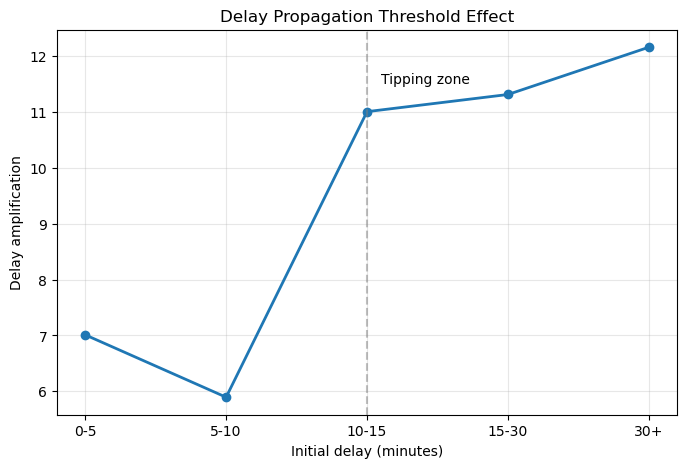

In [ ]:
delay_bins = ['0-5', '5-10', '10-15', '15-30', '30+']
amplification = [7.0104, 5.8946, 11.0029, 11.3097, 12.1554]

plt.figure(figsize=(8,5))

plt.plot(delay_bins, amplification, marker='o', linewidth=2)

# labels
plt.title('Delay Propagation Threshold Effect')
plt.xlabel('Initial delay (minutes)')
plt.ylabel('Delay amplification')


plt.axvline(x=2, linestyle='--', color='gray', alpha=0.5)  # ~10–15 min zone
plt.text(2.1, 11.5, 'Tipping zone', fontsize=10)

plt.grid(alpha=0.3)

plt.show()